# Comparação de Modelos: K-Means vs DBSCAN
## Quando o K-Means não é a melhor escolha

Nos notebooks anteriores usamos o **K-Means** — um algoritmo simples e poderoso, mas com uma **limitação importante**: ele assume que os clusters têm formato **aproximadamente esférico** e tamanhos parecidos. Quando os agrupamentos verdadeiros têm formas mais complexas, o K-Means falha.

Neste notebook, vamos comparar dois algoritmos de clusterização com filosofias bem diferentes:

| Característica            | K-Means                                      | DBSCAN                                                        |
|---------------------------|----------------------------------------------|---------------------------------------------------------------|
| **Tipo**                  | Baseado em centroides                        | Baseado em densidade                                          |
| **Precisa do K?**         | Sim, é um parâmetro obrigatório              | Não — descobre o número de clusters automaticamente           |
| **Formato dos clusters**  | Esféricos / convexos                         | Qualquer formato (curvo, alongado, irregular)                 |
| **Lida com ruído?**       | Não — todo ponto é atribuído a um cluster    | Sim — pontos isolados são marcados como **ruído** (rótulo -1) |
| **Parâmetros principais** | `n_clusters`                                 | `eps` (raio) e `min_samples` (vizinhos mínimos)               |

### Como o DBSCAN funciona (resumo)

DBSCAN = *Density-Based Spatial Clustering of Applications with Noise*.

A ideia é: um cluster é uma **região densa de pontos**.

- `eps`: o raio de vizinhança ao redor de cada ponto.
- `min_samples`: o número mínimo de pontos que precisam estar dentro do raio `eps` para considerar uma região "densa".

A partir disso o algoritmo classifica cada ponto como:
- **Core point** (ponto central): tem ≥ `min_samples` vizinhos dentro de `eps`.
- **Border point** (ponto de borda): está dentro do `eps` de um core point, mas não é core.
- **Noise point** (ruído): nem core nem border — fica isolado, com rótulo **-1**.

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')

## 2. Carregamento dos Dados

Para esta comparação, usaremos um dataset com **315 clientes** descritos por:

- **idade**: idade do cliente
- **score_risco**: score interno de risco do banco (0 a 100)

Esses dados foram construídos para ter **dois grupos com formato curvo (não convexo)** — uma situação em que o K-Means costuma ter dificuldades.

In [2]:
df = pd.read_csv('dados_padroes_clientes.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dimensões: 315 linhas × 2 colunas


,idade,score_risco
0,59,29.40
1,45,15.11
2,50,56.89
3,49,38.25
4,61,29.81
5,40,83.60
6,34,89.24
7,49,57.60
8,50,38.03
9,30,91.86


In [3]:
df.describe().round(2)

,idade,score_risco
count,315.00,315.00
mean,42.31,48.75
std,11.70,27.52
min,20.00,0.00
25%,34.00,23.64
50%,42.00,49.33
75%,50.00,73.54
max,65.00,100.00


## 3. Visualização dos Dados

Vamos olhar a distribuição dos pontos antes de aplicar qualquer algoritmo.

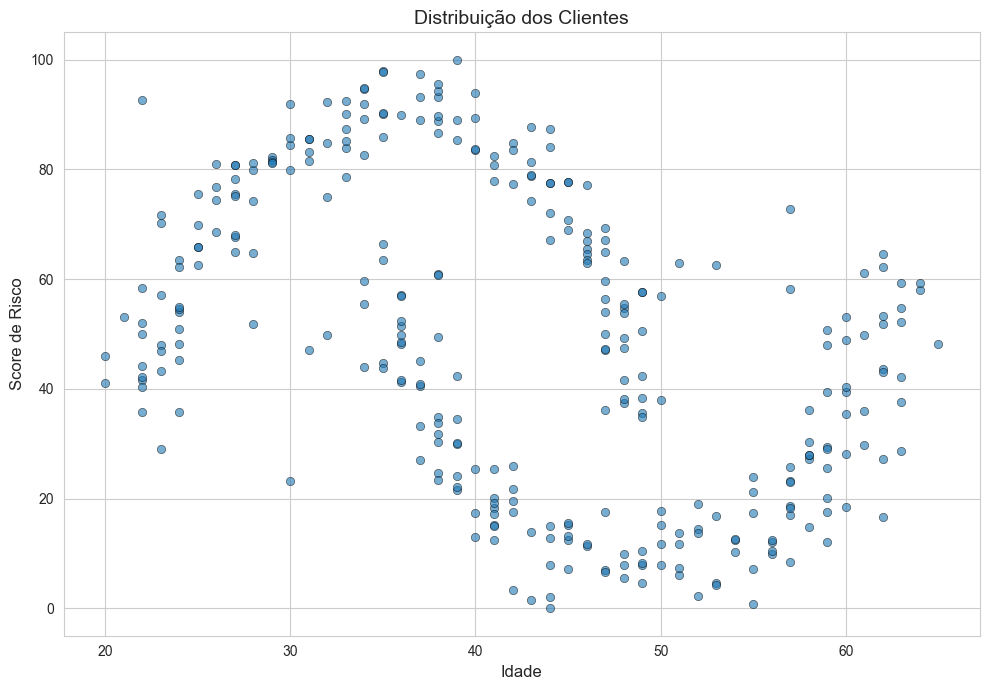

In [4]:
plt.figure(figsize=(10, 7))
plt.scatter(df['idade'], df['score_risco'], alpha=0.6, edgecolors='k', linewidths=0.5)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Score de Risco', fontsize=12)
plt.title('Distribuição dos Clientes', fontsize=14)
plt.tight_layout()
plt.show()

Observe que os pontos formam **duas estruturas curvas entrelaçadas** — um padrão claramente não esférico, com alguns pontos "soltos" que parecem ruído.

## 4. Padronização

Ambos os algoritmos são sensíveis à escala — precisamos padronizar.

In [5]:
scaler = StandardScaler()
X = df.values
X_scaled = scaler.fit_transform(X)
print(f'Shape: {X_scaled.shape}')

Shape: (315, 2)


## 5. K-Means

Vamos aplicar o K-Means com K=2 (já que visualmente parece haver duas estruturas).

In [6]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

print(f'Inércia: {kmeans.inertia_:.2f}')
print(f'Silhueta (K-Means): {silhouette_score(X_scaled, labels_km):.4f}')
print(f'\nDistribuição:')
print(pd.Series(labels_km).value_counts().sort_index())

Inércia: 266.82
Silhueta (K-Means): 0.4884

Distribuição:
0    159
1    156
Name: count, dtype: int64


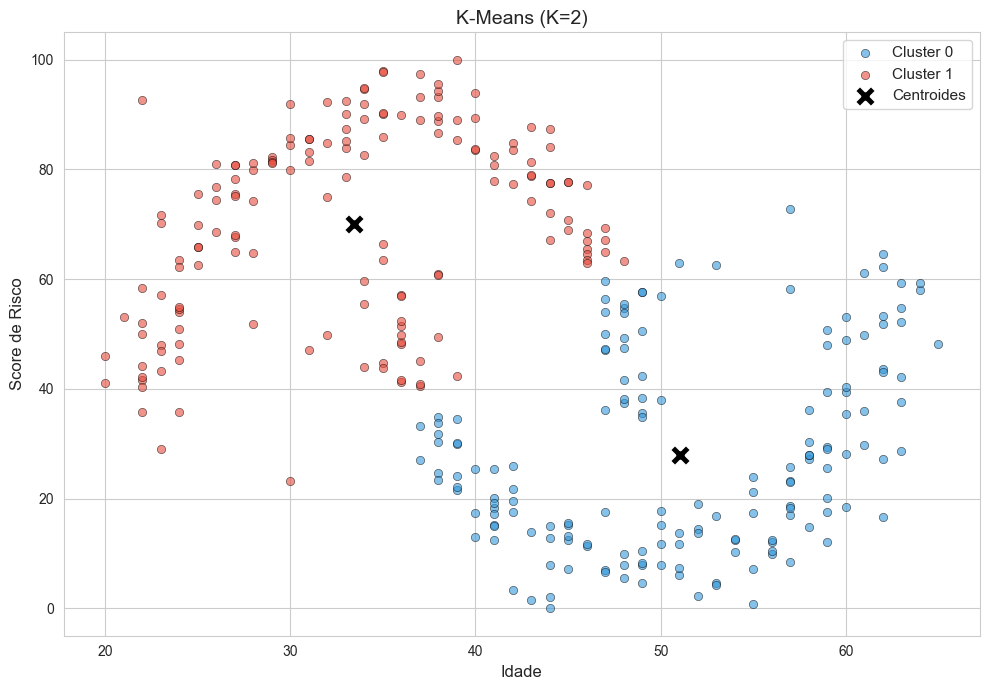

In [7]:
# Visualização
plt.figure(figsize=(10, 7))
cores_km = ['#3498db', '#e74c3c']
for c in range(2):
    pts = df[labels_km == c]
    plt.scatter(pts['idade'], pts['score_risco'], c=cores_km[c],
                alpha=0.6, edgecolors='k', linewidths=0.5,
                label=f'Cluster {c}')

centroides_orig = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroides_orig[:, 0], centroides_orig[:, 1],
            c='black', marker='X', s=250, edgecolors='white', linewidths=2,
            label='Centroides')

plt.xlabel('Idade', fontsize=12)
plt.ylabel('Score de Risco', fontsize=12)
plt.title('K-Means (K=2)', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Note como o K-Means **dividiu os dados com uma fronteira linear** (perpendicular à linha que une os dois centroides). Isso ignora completamente a estrutura curva real dos dados — exemplos da mesma "curva" foram colocados em clusters diferentes.

## 6. DBSCAN

### 6.1 Escolhendo o `eps`

O parâmetro `eps` é o que mais influencia o DBSCAN. Uma técnica clássica para escolhê-lo é o **gráfico de k-distância**:

1. Para cada ponto, calculamos a distância até seu **k-ésimo vizinho mais próximo** (com k = `min_samples`).
2. Ordenamos essas distâncias e plotamos.
3. O `eps` ideal fica no **"cotovelo"** desse gráfico — o ponto onde a curva começa a subir mais rapidamente.

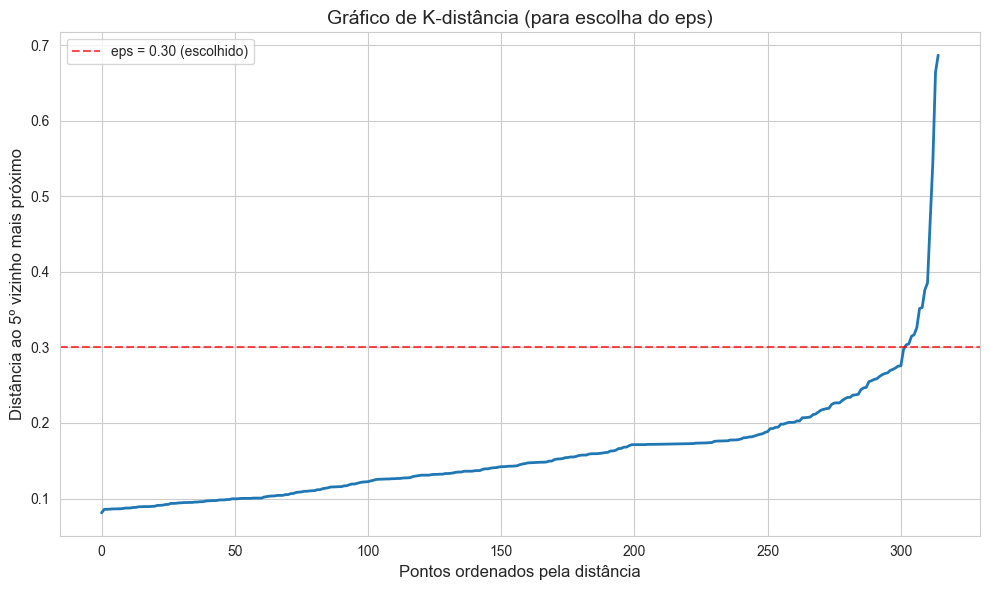

In [8]:
MIN_SAMPLES = 5

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
# Distância ao k-ésimo vizinho (última coluna)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances, linewidth=2)
plt.xlabel('Pontos ordenados pela distância', fontsize=12)
plt.ylabel(f'Distância ao {MIN_SAMPLES}º vizinho mais próximo', fontsize=12)
plt.title('Gráfico de K-distância (para escolha do eps)', fontsize=14)
plt.axhline(y=0.30, color='red', linestyle='--', alpha=0.7, label='eps = 0.30 (escolhido)')
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 Treinamento do DBSCAN

Vamos usar `eps = 0.30` e `min_samples = 5`.

In [9]:
dbscan = DBSCAN(eps=0.30, min_samples=MIN_SAMPLES)
labels_db = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_ruido = (labels_db == -1).sum()

print(f'Número de clusters encontrados: {n_clusters_db}')
print(f'Número de pontos classificados como ruído: {n_ruido}')
print(f'\nDistribuição:')
print(pd.Series(labels_db).value_counts().sort_index())

Número de clusters encontrados: 2
Número de pontos classificados como ruído: 5

Distribuição:
-1      5
 0    156
 1    154
Name: count, dtype: int64


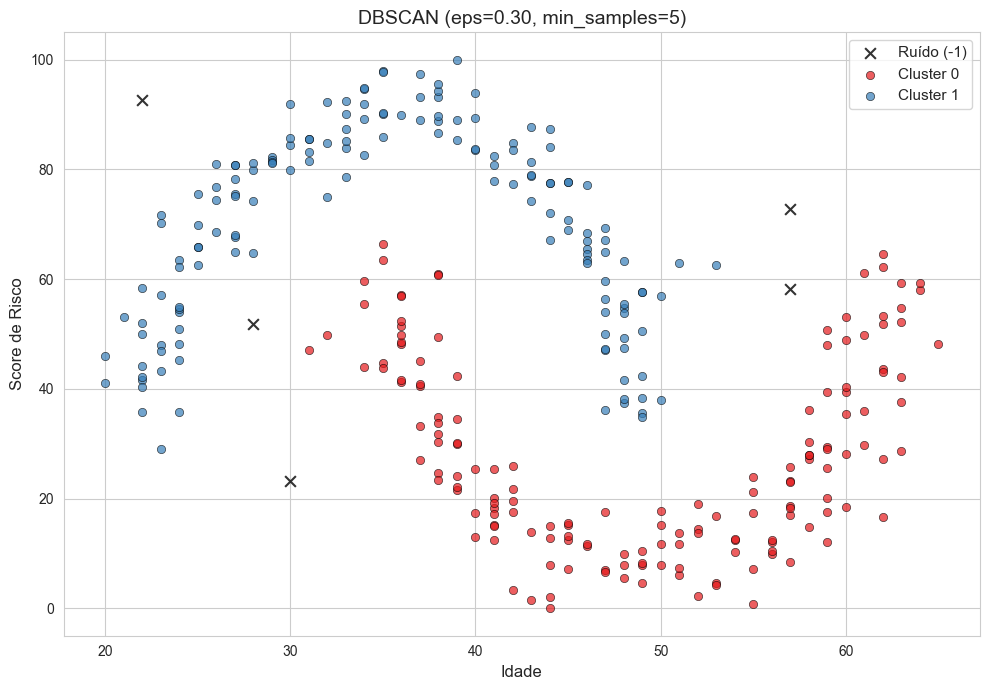

In [10]:
# Visualização do DBSCAN
plt.figure(figsize=(10, 7))

cores_db = sns.color_palette('Set1', n_colors=max(n_clusters_db, 1))
for cluster_id in sorted(set(labels_db)):
    mask = labels_db == cluster_id
    if cluster_id == -1:
        # ruído em preto, com 'X' menor
        plt.scatter(df.loc[mask, 'idade'], df.loc[mask, 'score_risco'],
                    c='black', marker='x', s=60, alpha=0.8,
                    label='Ruído (-1)')
    else:
        plt.scatter(df.loc[mask, 'idade'], df.loc[mask, 'score_risco'],
                    c=[cores_db[cluster_id]], alpha=0.7,
                    edgecolors='k', linewidths=0.5,
                    label=f'Cluster {cluster_id}')

plt.xlabel('Idade', fontsize=12)
plt.ylabel('Score de Risco', fontsize=12)
plt.title(f'DBSCAN (eps=0.30, min_samples={MIN_SAMPLES})', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Veja a diferença: o DBSCAN **acompanhou as curvas** dos dados e ainda **isolou os pontos de ruído** (marcados com X pretos).

### 6.3 Sensibilidade ao `eps`

O DBSCAN é muito sensível ao parâmetro `eps`. Vamos ver como ele se comporta para diferentes valores.

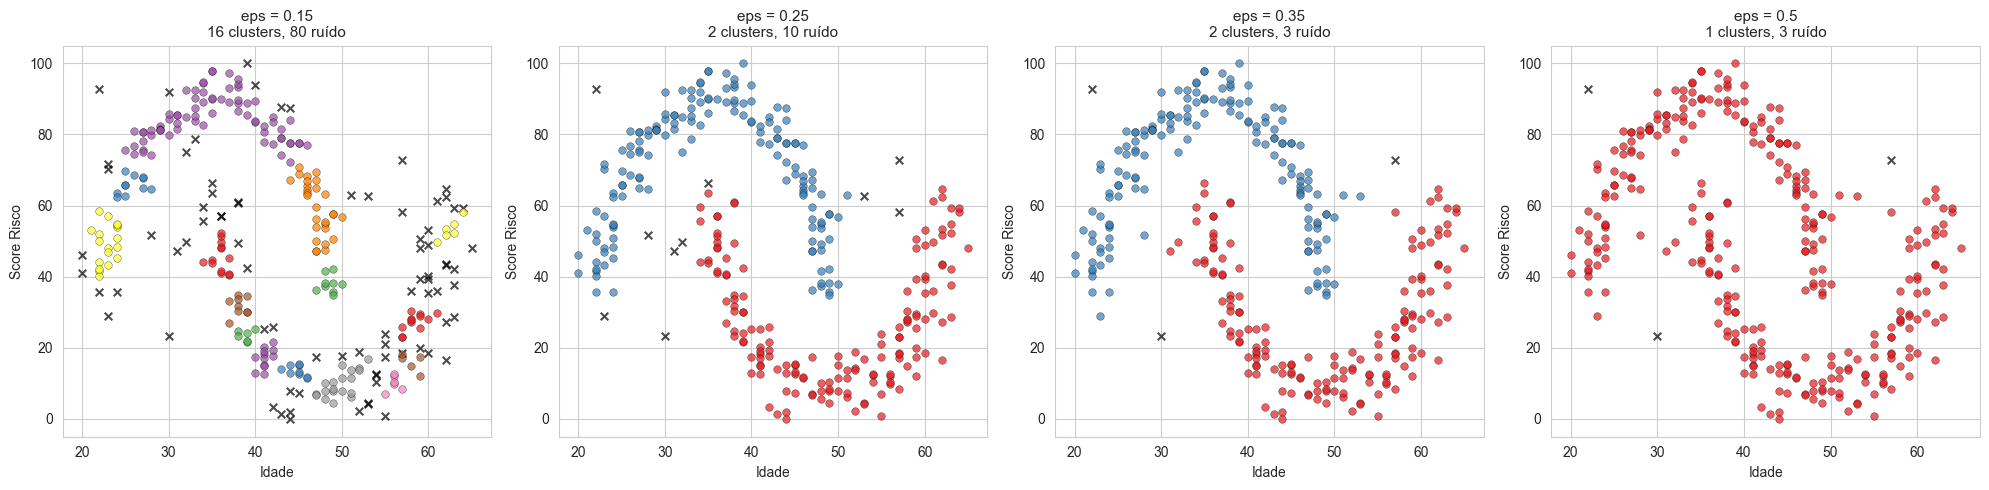

In [11]:
eps_values = [0.15, 0.25, 0.35, 0.50]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, eps in zip(axes, eps_values):
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit(X_scaled)
    n_c = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_r = (db.labels_ == -1).sum()

    cores = sns.color_palette('Set1', n_colors=max(n_c, 1))
    for cluster_id in sorted(set(db.labels_)):
        mask = db.labels_ == cluster_id
        if cluster_id == -1:
            ax.scatter(df.loc[mask, 'idade'], df.loc[mask, 'score_risco'],
                       c='black', marker='x', s=30, alpha=0.7)
        else:
            ax.scatter(df.loc[mask, 'idade'], df.loc[mask, 'score_risco'],
                       c=[cores[cluster_id % len(cores)]], alpha=0.7,
                       edgecolors='k', linewidths=0.3, s=30)

    ax.set_title(f'eps = {eps}\n{n_c} clusters, {n_r} ruído', fontsize=11)
    ax.set_xlabel('Idade')
    ax.set_ylabel('Score Risco')

plt.tight_layout()
plt.show()

- `eps` **muito pequeno** → muitos clusters fragmentados, muitos pontos de ruído.
- `eps` **muito grande** → tudo vira um único cluster.
- A escolha certa depende da densidade dos dados — por isso o gráfico de k-distância é tão útil.

## 7. Comparação Lado a Lado

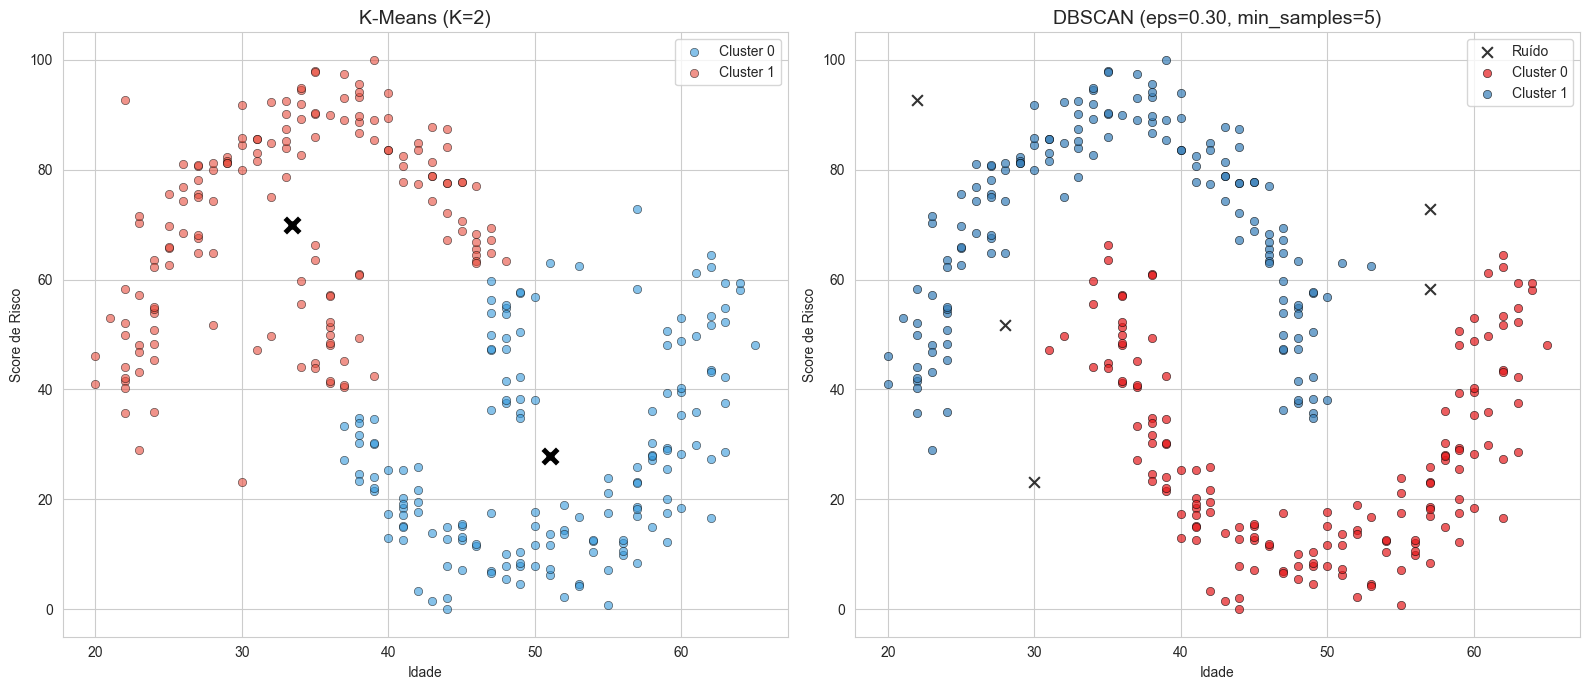

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# K-Means
for c in range(2):
    pts = df[labels_km == c]
    axes[0].scatter(pts['idade'], pts['score_risco'], c=cores_km[c],
                    alpha=0.6, edgecolors='k', linewidths=0.5,
                    label=f'Cluster {c}')
axes[0].scatter(centroides_orig[:, 0], centroides_orig[:, 1],
                c='black', marker='X', s=250, edgecolors='white', linewidths=2)
axes[0].set_title('K-Means (K=2)', fontsize=14)
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Score de Risco')
axes[0].legend()

# DBSCAN
cores_db = sns.color_palette('Set1', n_colors=max(n_clusters_db, 1))
for cluster_id in sorted(set(labels_db)):
    mask = labels_db == cluster_id
    if cluster_id == -1:
        axes[1].scatter(df.loc[mask, 'idade'], df.loc[mask, 'score_risco'],
                        c='black', marker='x', s=60, alpha=0.8,
                        label='Ruído')
    else:
        axes[1].scatter(df.loc[mask, 'idade'], df.loc[mask, 'score_risco'],
                        c=[cores_db[cluster_id]], alpha=0.7,
                        edgecolors='k', linewidths=0.5,
                        label=f'Cluster {cluster_id}')
axes[1].set_title(f'DBSCAN (eps=0.30, min_samples={MIN_SAMPLES})', fontsize=14)
axes[1].set_xlabel('Idade')
axes[1].set_ylabel('Score de Risco')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Métricas de Avaliação

Vamos comparar quantitativamente os dois modelos. Para o DBSCAN, calcular a silhueta exige um pequeno cuidado: **excluímos os pontos de ruído** antes de calcular.

In [13]:
# Silhueta para K-Means
sil_km = silhouette_score(X_scaled, labels_km)

# Silhueta para DBSCAN (sem o ruído)
mask_sem_ruido = labels_db != -1
if len(set(labels_db[mask_sem_ruido])) > 1:
    sil_db = silhouette_score(X_scaled[mask_sem_ruido], labels_db[mask_sem_ruido])
else:
    sil_db = float('nan')

resultados = pd.DataFrame({
    'Métrica': ['Nº de clusters', 'Pontos em ruído', 'Silhueta'],
    'K-Means': [len(set(labels_km)), 0, f'{sil_km:.4f}'],
    'DBSCAN': [n_clusters_db, n_ruido, f'{sil_db:.4f}']
}).set_index('Métrica')
resultados

,K-Means,DBSCAN
Métrica,,
Nº de clusters,2,2
Pontos em ruído,0,5
Silhueta,0.4884,0.3762


> **Cuidado com a silhueta**: ela pondera coesão e separação assumindo distâncias euclidianas, então pode **favorecer artificialmente** o K-Means em formas esféricas. Nem sempre o modelo com maior silhueta é o "melhor" — a inspeção visual e o conhecimento do problema também contam muito.

## 9. Quando usar cada um?

### Use **K-Means** quando:
- Você tem uma boa ideia de quantos clusters existem (ou pode usar o método do cotovelo / silhueta).
- Os clusters são relativamente **esféricos e compactos**.
- O dataset é **grande** (K-Means escala bem).
- Você precisa de uma solução **rápida e simples**.

### Use **DBSCAN** quando:
- Os clusters podem ter **formatos arbitrários**.
- Você **não sabe** o número de clusters.
- Os dados contêm **ruído / outliers** que você quer detectar.
- Os clusters podem ter **densidades parecidas** entre si (DBSCAN tem dificuldade quando densidades variam muito — para isso existe o HDBSCAN).

### Limitações comuns
| K-Means                                              | DBSCAN                                                       |
|------------------------------------------------------|--------------------------------------------------------------|
| Precisa do K (precisa testar ou estimar)             | Precisa ajustar `eps` e `min_samples`                        |
| Sensível à inicialização (use `n_init` alto)         | Performance cai em alta dimensão                             |
| Falha com formas não convexas                        | Tem dificuldade quando clusters têm densidades muito diferentes |
| Trata todos os pontos — não detecta outliers         | Pode descartar muitos pontos como ruído                      |

## 10. Resumo

Neste notebook vimos:

1. **K-Means** assume clusters esféricos e exige conhecer K — quando essa premissa falha, ele produz divisões artificiais.
2. **DBSCAN** descobre clusters por **densidade**, lida bem com formas arbitrárias e detecta **ruído** automaticamente.
3. Para escolher o `eps` do DBSCAN, use o **gráfico de k-distância**.
4. **Padronizar** os dados é essencial para ambos os algoritmos.
5. Não existe um algoritmo "melhor" — a escolha depende do **formato dos clusters** e dos **objetivos do problema**.

> **Dica final**: comece sempre com a **inspeção visual** dos seus dados (nem que seja após uma redução com PCA). Ela costuma sugerir qual algoritmo é mais adequado.